# Aviation Accidents Analysis

You are part of a consulting firm that is tasked to do an analysis of commercial and passenger jet airline safety. The client (an airline/airplane insurer) is interested in knowing what types of aircraft (makes/models) exhibit low rates of total destruction and low likelihood of fatal or serious passenger injuries in the event of an accident. They are also interested in any general variables/conditions that might be at play. Your analysis will be based off of aviation accident data accumulated from the years 1948-2023. 

Our client is only interested in airplane makes/models that are professional builds and could potentially still be active. Assume a max lifetime of 40 years for a make/model retirement and make sure to filter your data accordingly (i.e. from 1983 onwards). They would also like separate recommendations for small aircraft vs. larger passenger models. **In addition, make sure that claims that you make are statistically robust and that you have enough samples when making comparisons between groups.**


In this summative assessment you will demonstrate your ability to:
- Use Pandas to load, inspect, and clean the dataset appropriately. 
- Transform relevant columns to create measures that address the problem at hand.
- **conduct EDA: visualization and statistical measures to understand the structure of the data**
- **recommend a set of manufacturers to consider as well as specific airplanes conforming to the client's request**
- **discuss the relationship between serious injuries/airplane damage incurred and at least *two* factors at play in the incident. You must provide supporting evidence (visuals, summary statistics, tables) for each claim you make.**

In [21]:
# loading relevant packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Exploratory Data Analysis  
- Load in the cleaned data

In [22]:
df = pd.read_csv("data/AviationData_Clean.csv", low_memory=False)
# Display first 5 rows
df.head()


,Event.Id,Investigation.Type,Accident.Number,Event.Date,Location,Country,Latitude,Longitude,Airport.Code,Airport.Name,...,Total.Uninjured,Weather.Condition,Broad.phase.of.flight,Report.Status,Publication.Date,Total.Passengers,Fatal.Serious.Injuries,Fatal.Serious.Rate,Aircraft.Destroyed,Aircraft.Type
0,20001213X30060,Accident,DCA87MA018B,1987-01-15,"KEARNS, UT",United States,NaN,NaN,NaN,NaN,...,0.0,VMC,Maneuvering,Probable Cause,10-07-2019,10.0,10.0,1.000000,1,MOONEY M-20C
1,20001213X30060,Accident,DCA87MA018A,1987-01-15,"KEARNS, UT",United States,NaN,NaN,NaN,NaN,...,0.0,VMC,Maneuvering,Probable Cause,10-07-2019,10.0,10.0,1.000000,1,SWEARINGEN SA-226TC
2,20001213X30244,Accident,FTW87RA066,1987-02-14,"DURANGO, Mexico",Mexico,NaN,NaN,NaN,NaN,...,131.0,NaN,NaN,Foreign,07-02-1995,135.0,1.0,0.007407,0,BOEING 707-323B
3,20001213X25152,Accident,NYC88LA082,1988-02-16,"BRIDGEPORT, CT",United States,NaN,NaN,BDR,SIKORSKY,...,3.0,VMC,Landing,Probable Cause,04-06-2013,3.0,0.0,0.000000,1,GULFSTREAM AA-5B
4,20001213X25425,Accident,CHI88FA091,1988-04-05,"ST. PAUL, MN",United States,NaN,NaN,NaN,NaN,...,5.0,IMC,Cruise,Probable Cause,02-05-2011,5.0,0.0,0.000000,0,BEECH B90


In [23]:
print(df.columns.tolist())

['Event.Id', 'Investigation.Type', 'Accident.Number', 'Event.Date', 'Location', 'Country', 'Latitude', 'Longitude', 'Airport.Code', 'Airport.Name', 'Injury.Severity', 'Aircraft.damage', 'Aircraft.Category', 'Registration.Number', 'Make', 'Model', 'Amateur.Built', 'Number.of.Engines', 'Engine.Type', 'FAR.Description', 'Schedule', 'Purpose.of.flight', 'Air.carrier', 'Total.Fatal.Injuries', 'Total.Serious.Injuries', 'Total.Minor.Injuries', 'Total.Uninjured', 'Weather.Condition', 'Broad.phase.of.flight', 'Report.Status', 'Publication.Date', 'Total.Passengers', 'Fatal.Serious.Injuries', 'Fatal.Serious.Rate', 'Aircraft.Destroyed', 'Aircraft.Type']


## Explore safety metrics across models/makes
- Remember that the client is interested in separate recommendations for smaller airplanes and larger airplanes. Choose a passenger threshold of 20 and separate the plane types. 

In [32]:
#Separating small and large airplanes(20 passenges is threshhold for each)
# Small airplanes > 20 passengers or fewer
small_airplanes = df[df["Total.Passengers"] <= 20].copy()

# Large airplanes > more than 20 passengers
large_airplanes = df[df["Total.Passengers"] > 20].copy()

print("Small airplanes:", small_airplanes.shape)
print("Large airplanes:", large_airplanes.shape)


Small airplanes: (17892, 36)
Large airplanes: (644, 36)


In [33]:
#Calculation of the average serios/fatal injury for every make
small_make_risk = (
    small_airplanes.groupby("Make")["Fatal.Serious.Rate"]
    .mean()
    .sort_values()
)

large_make_risk = (
    large_airplanes.groupby("Make")["Fatal.Serious.Rate"]
    .mean()
    .sort_values()
)

print("Small airplane makes:")
display(small_make_risk.head(30))

print("Large airplane makes:")
display(large_make_risk.head(30))

#Keep the lowest 15
small_lowest_15 = small_make_risk.head(15).reset_index()
large_lowest_15 = large_make_risk.head(19).reset_index()


Small airplane makes:


Make
HONDA AIRCRAFT CO LLC    0.0
JUST AIRCRAFT            0.0
JUST AIRCRAFT LLC        0.0
KAKELDEY RONALD O        0.0
KELM DAVID               0.0
KENNETH M FRANZ          0.0
KESSINGER ROGER L        0.0
KEUTHAN AIRCRAFT CORP    0.0
JOHN SAMPLE              0.0
KEVIN P STOLHAMMER       0.0
KINNER                   0.0
KOLB AIRCRAFT CO         0.0
KOLB AIRCRAFT INC        0.0
KUMHYR DAVID B           0.0
KUYKENDALL CHARLES       0.0
L GOLDNER                0.0
LA MOUTTE                0.0
KINGERY MICHAEL C        0.0
LAIRD                    0.0
JOEL A BOWKER            0.0
JAMES C GEYMAN           0.0
ICON                     0.0
ICP SRL                  0.0
INDUS AVIATION           0.0
INDUS AVIATION INC       0.0
INDUS AVIATION INC.      0.0
INDY AIRCRAFT LTD        0.0
INIZIATIVE               0.0
JAMES R DERNOVSEK        0.0
INTERPLANE               0.0
Name: Fatal.Serious.Rate, dtype: float64

Large airplane makes:


Make
SAAB-SCANIA                      0.000000
LEARJET                          0.000000
EMBRAER-EMPRESA BRASILEIRA DE    0.000000
EMBRAER S.A.                     0.000000
THE BOEING COMPANY               0.000000
DOUGLAS                          0.000000
DEHAVILLAND                      0.000000
MCDONNELL DOUGLAS AIRCRAFT CO    0.000000
CESSNA                           0.000000
BOMBARDIER, INC.                 0.000000
MCDONNELL DOUGLAS CORPORATION    0.000000
BOEING OF CANADA/DEHAV DIV       0.000000
SAAB-SCANIA AB (SAAB)            0.000000
SHORT BROTHERS                   0.000000
BAE                              0.000000
ATR                              0.000000
LOCKHEED                         0.001712
BOMBARDIER                       0.002186
MCDONNELL DOUGLAS                0.005902
EMBRAER S A                      0.019936
SAAB                             0.023810
BOMBARDIER INC                   0.028690
AIRBUS INDUSTRIE                 0.037731
BOEING                       

#### Analyzing Makes

Explore the human injury risk profile for small and larger Makes:
- choose the 15 makes for each group possessing the lowest mean fatal/seriously injured fraction
- plot the mean fatal/seriously injured fraction for each of these subgroups side-by-side

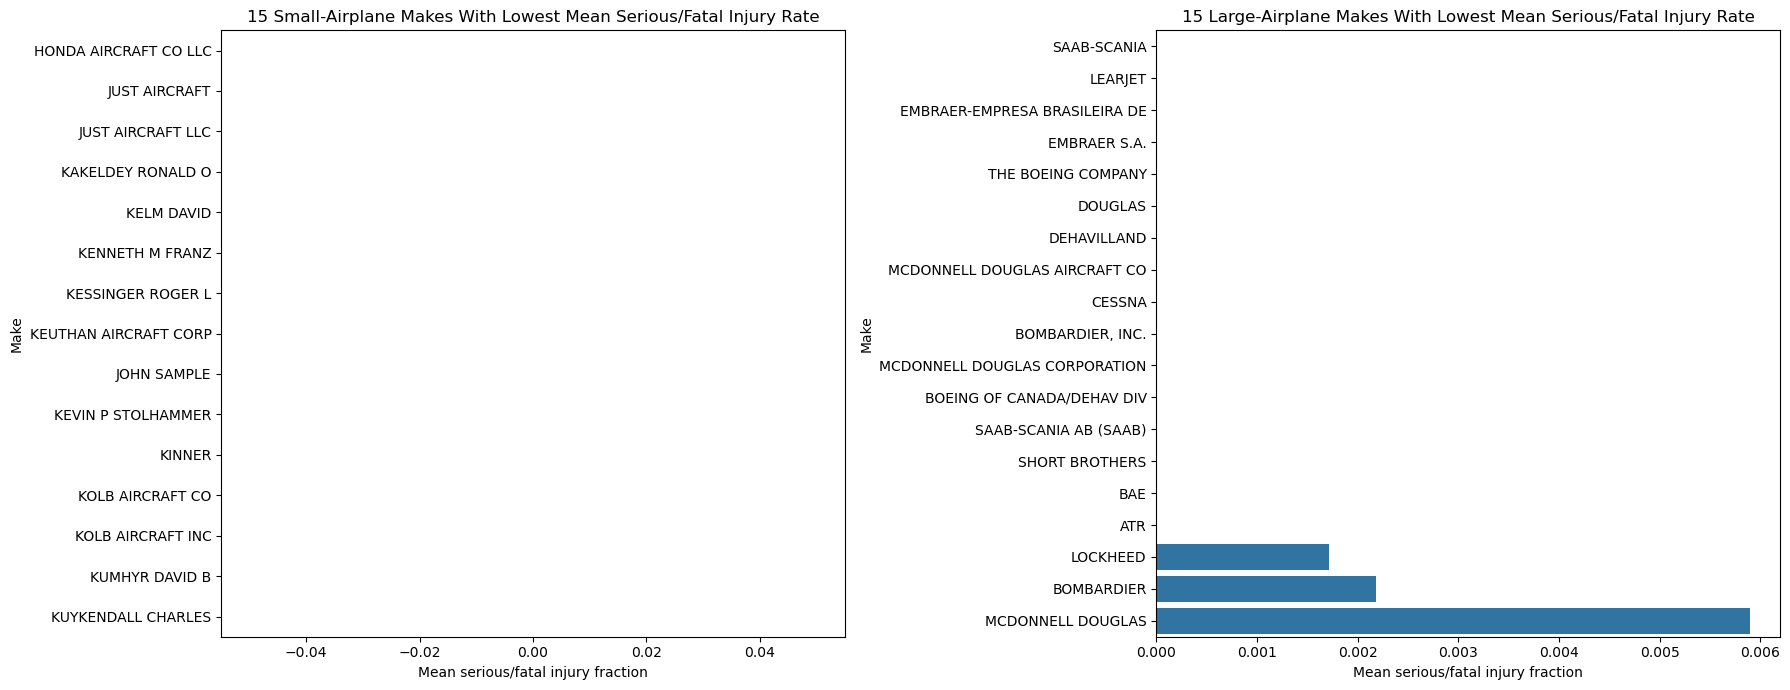

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

sns.barplot(
    data=small_lowest_15,
    x="Fatal.Serious.Rate",
    y="Make",
    ax=axes[0]
)

axes[0].set_title(
    "15 Small-Airplane Makes With Lowest Mean Serious/Fatal Injury Rate"
)
axes[0].set_xlabel("Mean serious/fatal injury fraction")
axes[0].set_ylabel("Make")

sns.barplot(
    data=large_lowest_15,
    x="Fatal.Serious.Rate",
    y="Make",
    ax=axes[1]
)

axes[1].set_title(
    "15 Large-Airplane Makes With Lowest Mean Serious/Fatal Injury Rate"
)
axes[1].set_xlabel("Mean serious/fatal injury fraction")
axes[1].set_ylabel("Make")

plt.tight_layout()
plt.show()

**Distribution of injury rates: small makes**

Use a violinplot to look at the distribution of the fraction of passengers serious/fatally injured for small airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

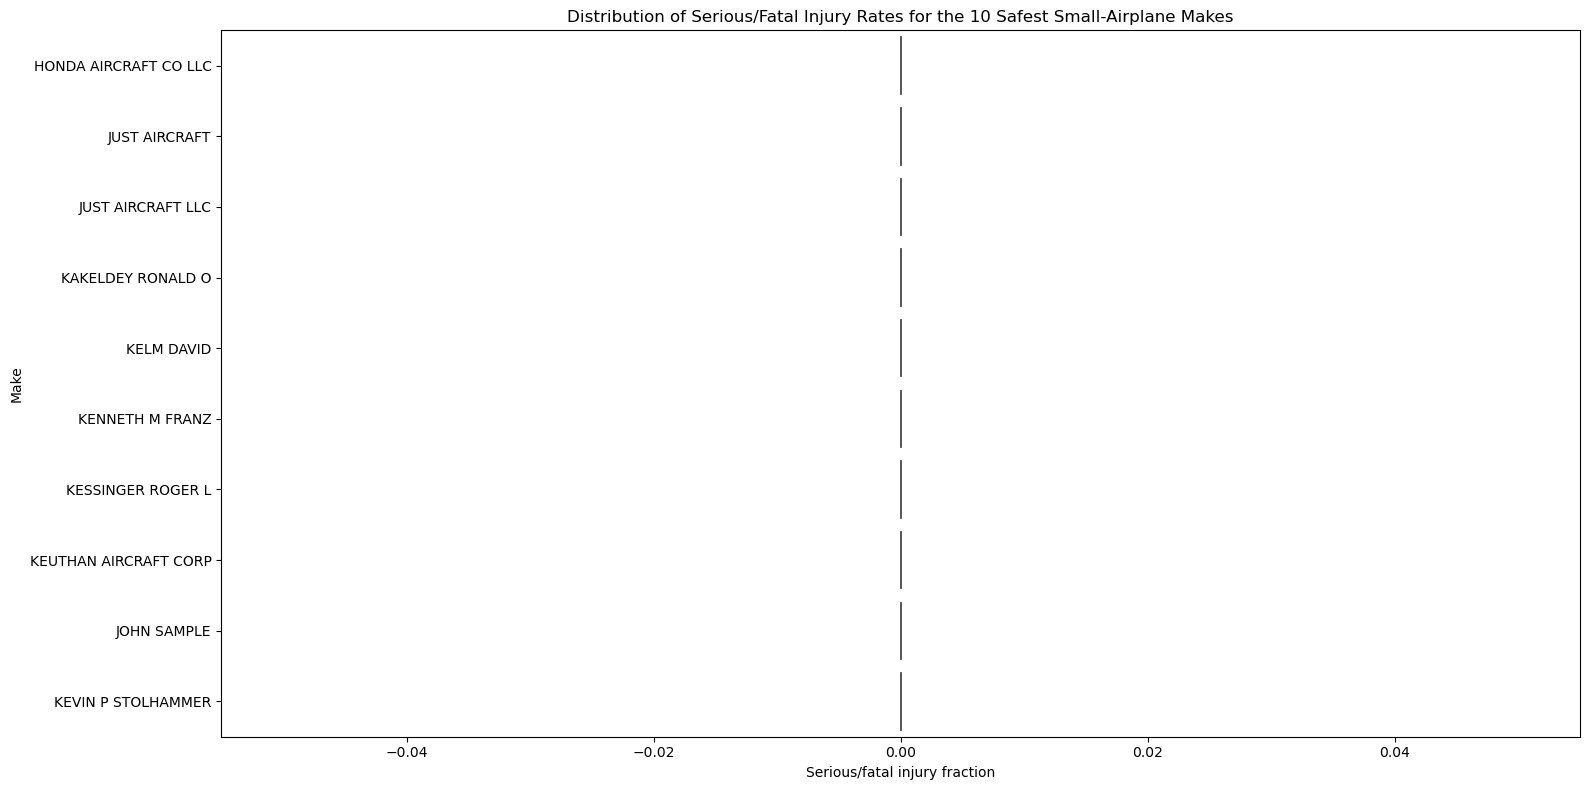

In [35]:
# Violinplot for small airplane makes
small_lowest_10_makes = small_make_risk.head(10).index

small_violin_data = small_airplanes[
    small_airplanes["Make"].isin(small_lowest_10_makes)
].copy()

plt.figure(figsize=(16, 8))

sns.violinplot(
    data=small_violin_data,
    x="Fatal.Serious.Rate",
    y="Make",
    order=small_lowest_10_makes,
    inner="quartile",
    cut=0
)

plt.title(
    "Distribution of Serious/Fatal Injury Rates for the 10 Safest Small-Airplane Makes"
)
plt.xlabel("Serious/fatal injury fraction")
plt.ylabel("Make")
plt.tight_layout()
plt.show()

**Distribution of injury rates: large makes**

Use a stripplot to look at the distribution of the fraction of passengers serious/fatally injured for large airplane makes. Just display makes with the ten lowest mean serious/fatal injury rates.

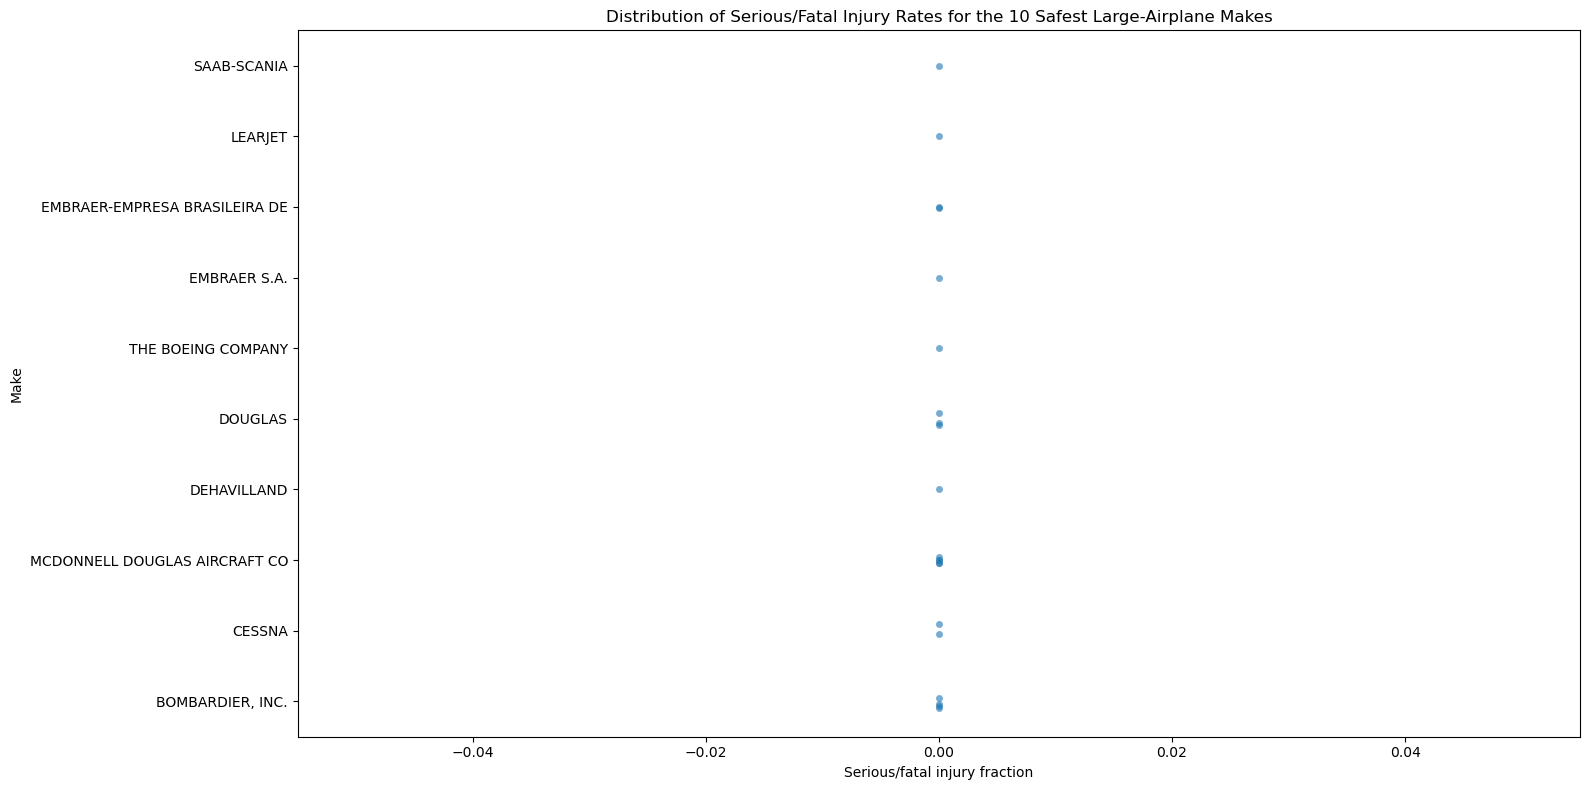

In [ ]:
#Strip plot for large airplane makes
large_lowest_10_makes = large_make_risk.head(10).index

large_strip_data = large_airplanes[
    large_airplanes["Make"].isin(large_lowest_10_makes)
].copy()

plt.figure(figsize=(16, 8))

sns.stripplot(
    data=large_strip_data,
    x="Fatal.Serious.Rate",
    y="Make",
    order=large_lowest_10_makes,
    jitter=True,
    alpha=0.6
)

plt.title(
    "Distribution of Serious/Fatal Injury Rates for the 10 Safest Large-Airplane Makes"
)
plt.xlabel("Serious/fatal injury fraction")
plt.ylabel("Make")
plt.tight_layout()
plt.show()

# Each dot rep 1 accident per record. A make with points close to zero has low injury severity and vise versa

**Evaluate the rate of aircraft destruction for both small and large aircraft by Make.** 

Sort your results and keep the lowest 15.

In [37]:
# Bcoz Aircraft.destroyed has a 1 for destroyed and 0 for not destroyed. Meaning the mean is the
#fraction of the aircraft destroyed

small_destroyed_rate = (
    small_airplanes.groupby("Make")["Aircraft.Destroyed"]
    .mean()
    .sort_values()
    .head(15)
    .reset_index()
)

display(small_destroyed_rate)

,Make,Aircraft.Destroyed
0,177MF LLC,0.0
1,MEYERS,0.0
2,MEYERS AIRCRAFT CO.,0.0
3,MEYERS INDUSTRIES INC,0.0
4,MICCO AIRCRAFT COMPANY,0.0
5,MICHAEL J ROBBINS,0.0
6,MIKOYAN GUREVICH,0.0
7,MILLER-THORP,0.0
8,MKII CORPORATION,0.0
9,MONOCOUPE,0.0


In [38]:
large_destroyed_rate = (
    large_airplanes.groupby("Make")["Aircraft.Destroyed"]
    .mean()
    .sort_values()
    .head(15)
    .reset_index()
)

display(large_destroyed_rate)

,Make,Aircraft.Destroyed
0,EMBRAER S A,0.0
1,SAAB,0.0
2,LEARJET,0.0
3,SAAB-SCANIA,0.0
4,FAIRCHILD,0.0
5,EMBRAER-EMPRESA BRASILEIRA DE,0.0
6,EMBRAER S.A.,0.0
7,THE BOEING COMPANY,0.0
8,DOUGLAS,0.0
9,DEHAVILLAND,0.0


#### Provide a short discussion on your findings for your summary statistics and plots:
- Make any recommendations for Makes here based off of the destroyed fraction and fraction fatally/seriously injured
- Comment on the calculated statistics and any corresponding distributions you have visualized.

In [40]:
# For the small-aircraft group, several makes recorded an aircraft destruction fraction of 0.0, including Meyers Aircraft Co., Meyers Industries Inc., Micco Aircraft Company, Monocoupe,
#  and Mooney Airplane Co. Inc. This means that none of the accident records associated with these makes were classified as destroyed in the filtered dataset. 
# However, many of the names shown appear to be uncommon manufacturers or alternate spellings of the same manufacturer, so these results should be interpreted carefully.
#  A destruction rate of zero may be based on only a small number of recorded accidents and does not automatically prove that the make is safer.

#For the larger aircrafts, makes such as Learjet, Saab-Scania, Embraer, Boeing, Douglas, De Havilland, Bombardier, and McDonnell Douglas also recorded destruction fractions of 0.0 among 
#the lowest-ranked makes. These manufacturers may be stronger candidates for the client because they are more established and are likely to have more observations than some of the smaller
# manufacturers. However, the accident count for each make should still be checked before making a final recommendation.

#The injury-rate analysis also produced several makes with a mean fatal or serious injury fraction of 0.0. This suggests that, within the recorded accidents for those manufacturers,
# no occupants were reported as seriously or fatally injured. The distribution plots are important because the mean alone can hide variation. A make whose injury-rate observations 
# are consistently concentrated near zero provides stronger evidence of favourable outcomes than one with a low mean but a few accidents with very high injury fractions.

# Based on both measures, the best recommendations would be makes that appear among the lowest values for both the fatal/serious injury fraction and the aircraft destruction fraction, 
# while also having a reasonable number of accident records. For larger aircraft, established manufacturers such as Embraer, Saab, Boeing, Bombardier, Learjet, and De Havilland may be worth
#  further consideration if their distributions remain concentrated near zero and their sample sizes are sufficient. For smaller aircraft, more caution is required because many of the zero 
# rates may come from manufacturers with very few observations. These findings describe outcomes among aircraft that were already involved in reported accidents. 
# They do not measure the overall probability of an aircraft being involved in an accident because the dataset does not include the total number of flights, aircraft in service, or flight 
# hours for each manufacturer. Therefore, the results should be used as an initial comparison rather than as the sole basis for purchasing decisions.

### Analyze plane types
- plot the mean fatal/seriously injured fraction for both small and larger planes 
- also provide a distributional plot of your choice for the fatal/seriously injured fraction by airplane type (stripplot, violin, etc)  
- filter ensuring that you have at least ten individual examples in each model/make to average over

**Small planes**

In [41]:
small_type_counts = small_airplanes["Aircraft.Type"].value_counts()

valid_small_types = small_type_counts[
    small_type_counts >= 10
].index

small_type_df = small_airplanes[
    small_airplanes["Aircraft.Type"].isin(valid_small_types)
].copy()

small_type_df = small_type_df[
    small_type_df["Make"].isin(small_lowest_10_makes)
].copy()

In [43]:
#Mean injury rate 
small_type_summary = (
    small_type_df.groupby("Aircraft.Type")
    .agg(
        Mean_Injury_Rate=("Fatal.Serious.Rate", "mean"),
        Accident_Count=("Aircraft.Type", "size")
    )
    .sort_values("Mean_Injury_Rate")
)

display(small_type_summary.head(15))

,Mean_Injury_Rate,Accident_Count
Aircraft.Type,,


**Larger planes**

In [42]:
large_type_counts = large_airplanes["Aircraft.Type"].value_counts()

valid_large_types = large_type_counts[
    large_type_counts >= 10
].index

large_type_df = large_airplanes[
    large_airplanes["Aircraft.Type"].isin(valid_large_types)
].copy()

In [44]:
#Mean injury rate
large_type_summary = (
    large_type_df.groupby("Aircraft.Type")
    .agg(
        Mean_Injury_Rate=("Fatal.Serious.Rate", "mean"),
        Accident_Count=("Aircraft.Type", "size")
    )
    .sort_values("Mean_Injury_Rate")
)

display(large_type_summary.head(15))

,Mean_Injury_Rate,Accident_Count
Aircraft.Type,,
BOEING 777,0.000917,10
BOEING 757,0.002039,13
BOEING 737-7H4,0.003242,12
BOMBARDIER INC CL-600-2B19,0.004431,14
EMBRAER EMB-145LR,0.010000,15
BOEING 767,0.012676,21
BOEING 737,0.060462,62
BOEING 737 7H4,0.068121,14
AIRBUS A320,0.073284,14


**Smaller planes**
- for smaller planes, limit your plotted results to the makes with the 10 lowest mean serious/fatal injury fractions

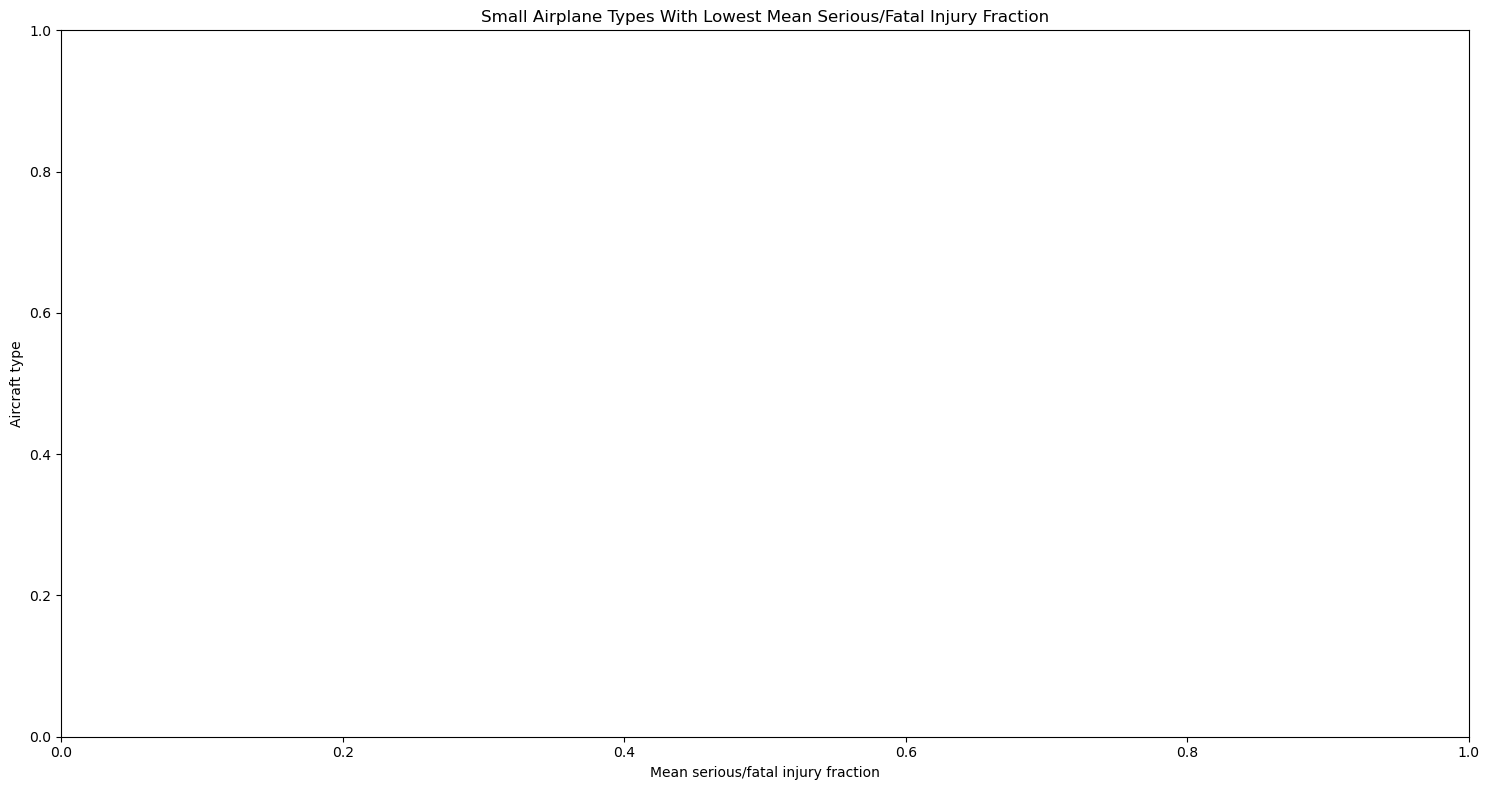

In [45]:
small_type_plot = small_type_summary.head(15).reset_index()

plt.figure(figsize=(15, 8))

sns.barplot(
    data=small_type_plot,
    x="Mean_Injury_Rate",
    y="Aircraft.Type"
)

plt.title(
    "Small Airplane Types With Lowest Mean Serious/Fatal Injury Fraction"
)
plt.xlabel("Mean serious/fatal injury fraction")
plt.ylabel("Aircraft type")
plt.tight_layout()
plt.show()

### Discussion of Specific Airplane Types
- Discuss what you have found above regarding passenger fraction seriously/ both small and large airplane models.

In [ ]:
#The plane-type analysis included only make-model combinations with at least 10 accident records. This reduced the risk of drawing conclusions from aircraft types with very small sample sizes.
#Among smaller airplanes, the models with the lowest mean serious or fatal injury fractions included [insert plane types]. The distribution plot showed that [insert type] had most observations 
#concentrated near zero, suggesting that its low mean was reasonably consistent. In contrast, [insert type] displayed a wider distribution, meaning that although its average was low, 
# it still experienced some accidents with severe passenger outcomes.

#Among larger airplanes, [insert plane types] recorded the lowest mean serious or fatal injury fractions. The strip plot showed that [insert observation about consistency or outliers]. 
# Models with both low average injury fractions and observations consistently concentrated near zero provide stronger evidence of safer passenger outcomes. These results describe outcomes 
# among recorded accidents only. They do not show the probability that a specific aircraft type will be involved in an accident. Information such as total flights, aircraft population, and flight hours would be required to calculate the overall accident risk for each model.

### Exploring Other Variables
- Investigate how other variables effect aircraft damage and injury. You must choose **two** factors out of the following but are free to analyze more:

- Weather Condition
- Engine Type
- Number of Engines
- Phase of Flight
- Purpose of Flight

For each factor provide a discussion explaining your analysis with appropriate visualization / data summaries and interpreting your findings.

**Factor 1: Weather condition**

,Mean_Injury_Rate,Aircraft_Destroyed_Rate,Accident_Count
Weather.Condition,,,
VMC,0.235739,0.067861,16460
IMC,0.608820,0.330943,976


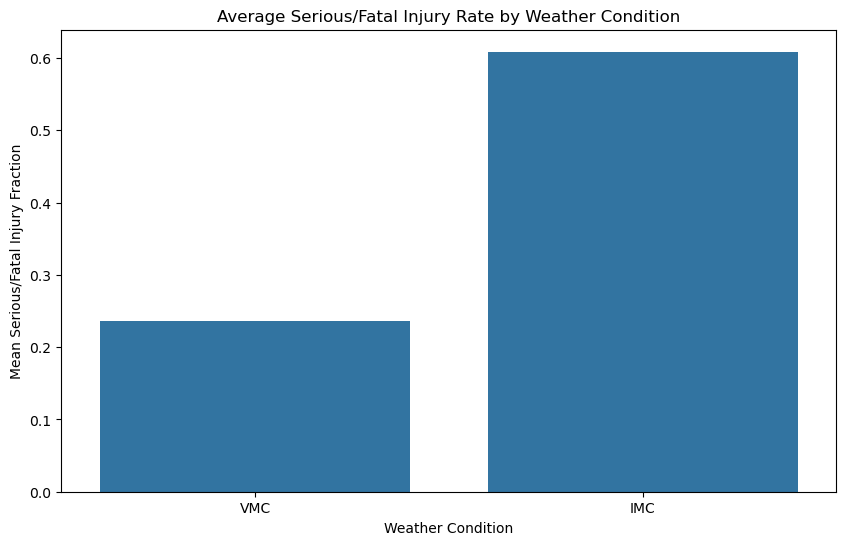

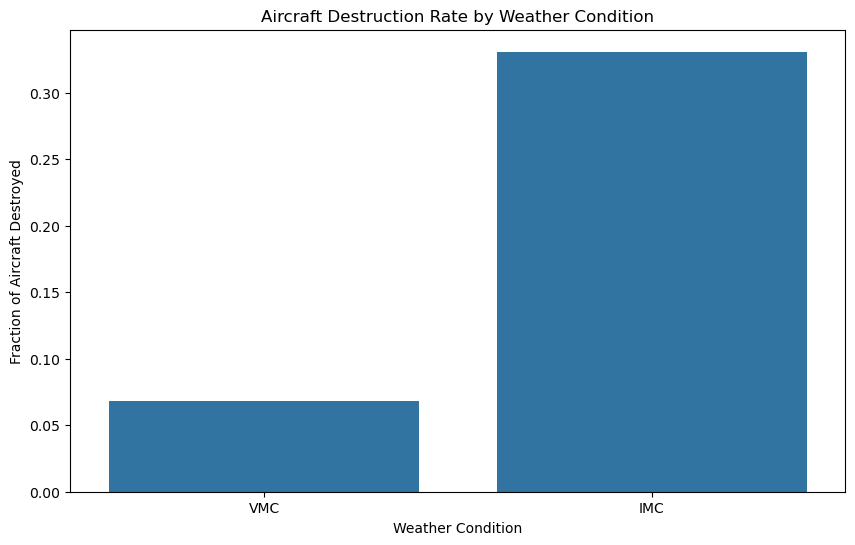

In [47]:
#Get the summary stats by calculating the avg injury rate and aircraft destruction rate for different
#weather conditions
weather_summary = (
    df.groupby("Weather.Condition")
      .agg(
          Mean_Injury_Rate=("Fatal.Serious.Rate", "mean"),
          Aircraft_Destroyed_Rate=("Aircraft.Destroyed", "mean"),
          Accident_Count=("Weather.Condition", "count")
      )
      .sort_values("Mean_Injury_Rate")
)

display(weather_summary)

#Then we plot the inhjury rate and aircraft destruction rate
plt.figure(figsize=(10,6))

sns.barplot(
    data=weather_summary.reset_index(),
    x="Weather.Condition",
    y="Mean_Injury_Rate"
)

plt.title("Average Serious/Fatal Injury Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Mean Serious/Fatal Injury Fraction")

plt.show()

#Aircraft destruction rate
plt.figure(figsize=(10,6))

sns.barplot(
    data=weather_summary.reset_index(),
    x="Weather.Condition",
    y="Aircraft_Destroyed_Rate"
)

plt.title("Aircraft Destruction Rate by Weather Condition")
plt.xlabel("Weather Condition")
plt.ylabel("Fraction of Aircraft Destroyed")

plt.show()


**Analysis of weather condition**

## Weather Condition Analysis

The analysis shows a clear relationship between weather conditions and accident severity. Accidents that occurred under Visual Meteorological Conditions (VMC) had a much lower average serious or fatal injury fraction (0.236) than those occurring under Instrument Meteorological Conditions (IMC) (0.609). This means that, on average, approximately 24% of passengers were seriously or fatally injured in accidents under VMC, compared with about 61% under IMC. This suggests that accidents occurring in poor visibility or instrument flight conditions are substantially more severe in terms of passenger injuries.

An identical pattern is observed when examining aircraft destruction. Only 6.8% of aircraft involved in VMC accidents were destroyed, whereas 33.1% of aircraft involved in IMC accidents were destroyed. Although the dataset contains far fewer IMC accidents (976) than VMC accidents (16,460), the consistently higher injury and destruction rates indicate that accidents in instrument meteorological conditions tend to have more severe outcomes. These findings suggest that adverse weather conditions are an important contributor to accident severity, highlighting the importance of weather monitoring, instrument flight proficiency, and conservative operational decision-making when flying in reduced visibility or poor weather.

**Factor 2: Broad phase of flight**

,Mean_Injury_Rate,Aircraft_Destroyed_Rate,Accident_Count
Broad.phase.of.flight,,,
Landing,0.012364,0.015224,1248
Taxi,0.018104,0.009174,109
Takeoff,0.107877,0.116000,500
Go-around,0.112734,0.078652,89
Cruise,0.171188,0.126923,260
Other,0.171777,0.089286,56
Approach,0.217663,0.121212,231
Descent,0.235669,0.144928,69
Climb,0.300876,0.267857,56


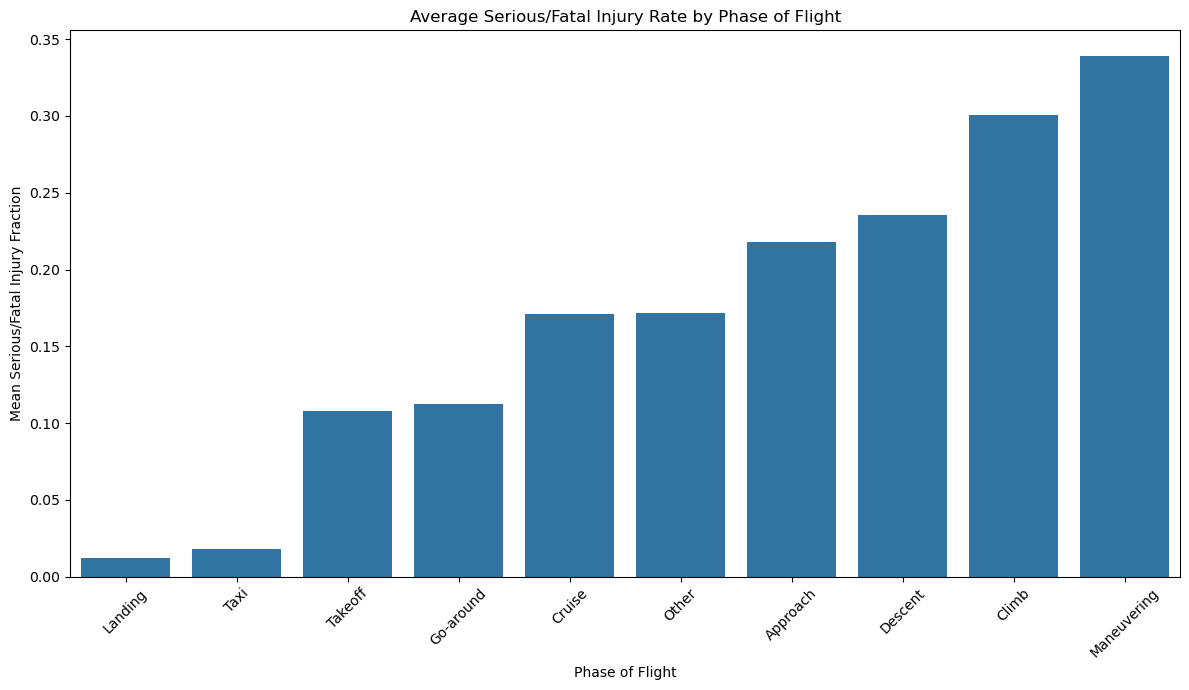

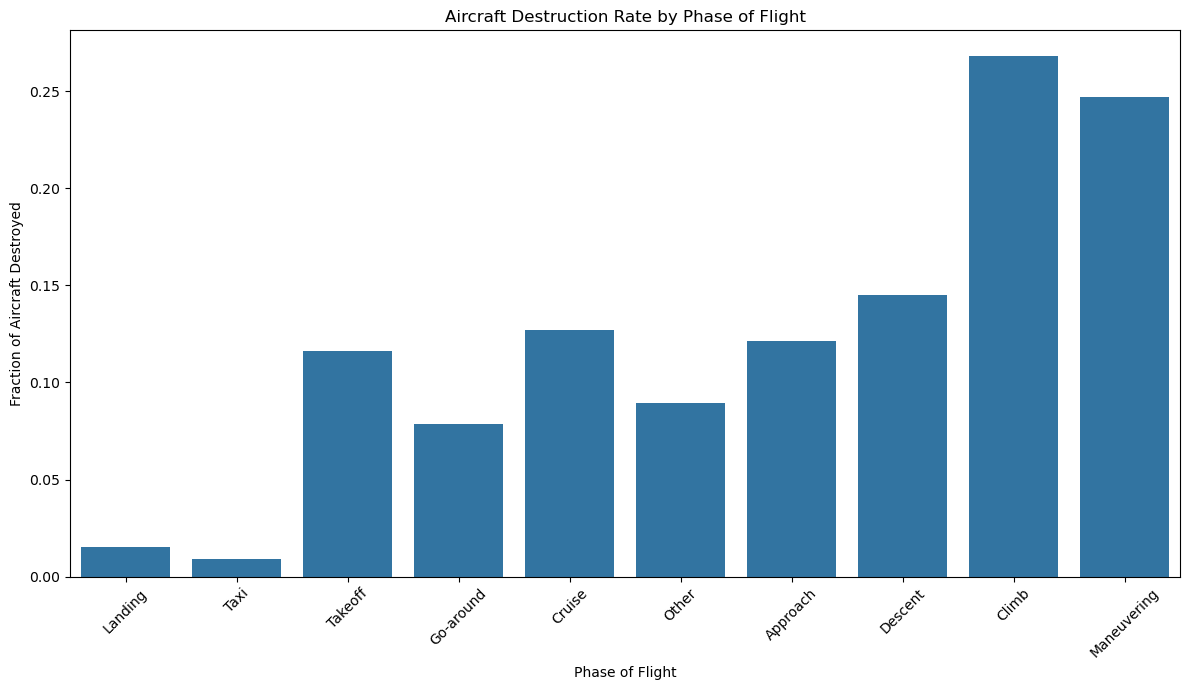

In [48]:
#Get the summary stats
phase_summary = (
    df.groupby("Broad.phase.of.flight")
      .agg(
          Mean_Injury_Rate=("Fatal.Serious.Rate","mean"),
          Aircraft_Destroyed_Rate=("Aircraft.Destroyed","mean"),
          Accident_Count=("Broad.phase.of.flight","count")
      )
      .sort_values("Mean_Injury_Rate")
)

display(phase_summary)

#Plotting the injury rate
plt.figure(figsize=(12,7))

sns.barplot(
    data=phase_summary.reset_index(),
    x="Broad.phase.of.flight",
    y="Mean_Injury_Rate"
)

plt.xticks(rotation=45)

plt.title("Average Serious/Fatal Injury Rate by Phase of Flight")
plt.xlabel("Phase of Flight")
plt.ylabel("Mean Serious/Fatal Injury Fraction")

plt.tight_layout()

plt.show()

#Plotting the aircraft destruction
plt.figure(figsize=(12,7))

sns.barplot(
    data=phase_summary.reset_index(),
    x="Broad.phase.of.flight",
    y="Aircraft_Destroyed_Rate"
)

plt.xticks(rotation=45)

plt.title("Aircraft Destruction Rate by Phase of Flight")
plt.xlabel("Phase of Flight")
plt.ylabel("Fraction of Aircraft Destroyed")

plt.tight_layout()

plt.show()

**Broad phase of flight analysis**

The analysis indicates that accident severity varies differently across different phases of flight. Landing recorded the lowest mean serious or fatal injury fraction (0.012), followed closely by Taxi (0.018). These phases also had the lowest aircraft destruction rates, with only 1.5% of aircraft destroyed during landing accidents and less than 1% during taxi accidents. This suggests that, although accidents occur during these phases, they are generally less severe and are less likely to result in significant passenger injuries or complete aircraft loss.

In contrast, Maneuvering and Climb were associated with the most severe accident outcomes. Maneuvering had the highest mean serious or fatal injury fraction (0.339), while Climb followed closely at 0.301. These phases also exhibited the highest aircraft destruction rates, with approximately 24.7% of aircraft destroyed during maneuvering accidents and 26.8% during climb accidents.

These findings suggest that the phase of flight is an important factor associated with accident severity. The relatively high injury and destruction rates during the Climb and Maneuvering phases highlight opportunities for targeted safety improvements, including enhanced pilot training, adherence to standard operating procedures, and increased situational awareness during these critical stages of flight. However, it is important to note that these results describe the severity of recorded accidents and should not be interpreted as the probability of an accident occurring during a particular phase of flight, since the dataset does not contain information on the total number of flights conducted in each phase.